# `mu_to_H0` — Second-to-Third Rung Distance Ladder Demo

This notebook demonstrates how to use `mu_to_H0.py` to measure H0 from Cepheid distance moduli to calibrator SN host galaxies.

**Concept:**  
The full SH0ES distance ladder runs Cepheids → calibrator SNe → Hubble-flow SNe.  
`mu_to_H0` takes the second rung as a *user input* (Cepheid distance moduli μ to each host) and fits the third rung (Hubble-flow SNe) to recover H0 and M_B, using the full SN covariance matrix.

**Default data files** (shipped with the repo, pre-built from the SH0ES R22 subset):
- `data/SH0ES22_partial_y.npy` — SN magnitude observables
- `data/SH0ES22_partial_C.npy` — SN covariance matrix
- `data/SH0ES22_partial_labels.csv` — row metadata (label, type, host)

To use your own SN selection instead, run `prep_SN_data.ipynb` to produce `data/custom_*` and change the filenames in the load cell below.

## 1. Load SH0ES second and third rung data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mu_to_H0 import solve_H0

# Default: pre-built SH0ES R22 subset shipped with the repo.
# To use your own selection, run prep_SN_data.ipynb and switch these to data/custom_*
y      = np.load('data/SH0ES22_partial_y.npy')
C      = np.load('data/SH0ES22_partial_C.npy')
labels = pd.read_csv('data/SH0ES22_partial_labels.csv')

cal = labels[labels['type'] == 'CAL']
hf  = labels[labels['type'] == 'HF']

# What's in ```y``` (observable) vector?

## Hubble's law:
The Hubble constant is defined in units of velocity per distance (km/s/Mpc). We combine that with the definition of distance moduli and multi-order approximation for the redshift-velocity relation:
$$ 
\begin{cases}
H_0 \equiv v [\mathrm{km/s}] \cdot d^{-1} [\mathrm{Mpc}] & \\
\mu \equiv m - M = 5\log_{10}\frac{d}{10} \\
z \approx v/c & (z\ll 1; \text{see, e.g., Visser 2004 and Riess+22 for higher order terms})
\end{cases}
$$

Now rewriting the first term in parsecs
$$ H_0 = (cz) \cdot \left(10^{-6} \cdot 10 \cdot \frac{d [\mathrm{pc}]}{10 [\mathrm{pc}]}\right)^{-1} $$
and taking a log
$$\log_{10} H_0 = \log_{10}(cz) - \log_{10}\left(\frac{d}{10}\right) + 5$$
allows us to use a magnitude system (distance modulus)
$$\log_{10} H_0 = \log_{10}(cz) - \frac{\mu}{5} + 5\ .$$
separating $\mu$ into apparent and absolute magnitudes, we get
$$5\log_{10} H_0 = 5\log_{10}(cz) - \left(m - M\right) + 25\ .$$

As mentioned above, $v$--$z$ relation can be expanded into higher order terms to account for the acceleration, etc., and those terms are often indicated in the literature as $\log_{10}cz\{\}$.

Now, we have a system of equations:
$$
\begin{cases}
    \mu_\mathrm{host} = \left(m_\mathrm{SN,\ calib} - M_\mathrm{SN}\right)  & \mathrm{(2nd\ rung)} \\
    5\log_{10} H_0 = 5\log_{10}\left[c\cdot\{z_\mathrm{HF}+\mathcal{O}(z^2)+\cdots\}\right] - \left(m_\mathrm{SN,\ HF} - M\right) + 25 & \mathrm{(3rd\ rung)}
\end{cases}
$$


which we rewrite as
$$
\begin{cases}
    m_\mathrm{SN,\ calib} &= \mu_\mathrm{host} + M_\mathrm{SN} & \mathrm{(2nd\ rung)} \\
    m_\mathrm{SN,\ HF} - 5\log_{10}cz\{\} - 25 &= M_\mathrm{SN} - 5\log_{10} H_0 & \mathrm{(3rd\ rung)}
\end{cases}\ .
$$
The LHS represent observed quantities, and they are in the ```y``` vector. Covariance between those data points are given as a matrix ```C```.

In reality, the first rung, which determines $\mu_\mathrm{host}$ from other distance indicators like Cepheids, TRGB, etc., have covariance to later rungs, but we omit them in this workshop for simplicity.

## 2. Provide Cepheid distance moduli and uncertainties

The dict `mu_host` maps each host galaxy name to its Cepheid distance modulus (magnitudes),
and `sigma_mu_host` maps each host to its 1-sigma distance uncertainty.

**Replace the values below with your own Cepheid measurements.**

The demo distance values are taken from Table 6 in Riess et al. (R22).

Per-host distance errors are fully correlated across all SNe in the same host
and are propagated into the fit covariance matrix automatically.

In [2]:
mu_host_unique = [
    29.178, 32.920, 34.527, 32.830, 33.709, 32.563, 32.541, 31.378,
    31.287, 31.491, 31.450, 32.051, 32.612, 32.464, 33.014, 32.331,
    32.120, 31.936, 32.804, 31.635, 31.722, 31.603, 30.844, 30.835,
    31.812, 32.599, 33.116, 31.772, 30.546, 33.094, 32.223, 32.363,
    31.628, 33.246, 32.500, 33.187, 32.848
]

sigma_host_unique = [
    0.041, 0.123, 0.250, 0.109, 0.149, 0.074, 0.059, 0.056,
    0.037, 0.061, 0.064, 0.099, 0.154, 0.158, 0.165, 0.076,
    0.051, 0.034, 0.080, 0.089, 0.071, 0.116, 0.128, 0.050,
    0.084, 0.205, 0.074, 0.052, 0.205, 0.099, 0.120, 0.125,
    0.117, 0.119, 0.153, 0.067
]

Host_unique = [
    "M101", "M1337", "N105A", "N0691", "N976A", "N1015", "N1309", "N1365",
    "N1448", "N1559", "N2442", "N2525", "N2608", "N3021", "N3147", "N3254",
    "N3370", "N3447", "N3583", "N3972", "N3982", "N4038", "N4424", "N4536",
    "N4639", "N4680", "N5468", "N5584", "N5643", "N5728", "N5861", "N5917",
    "N7250", "N7329", "N7541", "N7678", "U9391"
]
mu_host       = {host.lower(): mu    for host, mu    in zip(Host_unique, mu_host_unique)}
sigma_mu_host = {host.lower(): sigma for host, sigma in zip(Host_unique, sigma_host_unique)}

In [ ]:
# modify distance to any of the hosts -- note host names are in the lower case

mu_host_modified = mu_host.copy()
sigma_mu_host_modified = sigma_mu_host.copy()

mu_host_modified['n5584'] = mu_host_modified['n5584'] + 0.1 # adjust distance
mu_host_modified['n3370'] = mu_host_modified['n3370'] - 0.2 # adjust distance
mu_host_modified['n3447'] = 31.0                   # manually set the distance to a specific value
mu_host_modified['n2525'] = np.nan                 # remove a host by setting its distance to NaN

sigma_mu_host_modified['n2442'] = 0.3  # manually set/inflate the uncertainty of a host distance

## 3. Solve for H0

In [4]:
# NOTE the uncertainty is approximation since it does not account for covariance between host distances.

print('*** BEFORE ***')
result = solve_H0(mu_host, sigma_mu_host=sigma_mu_host, y=y, C=C, labels=labels)

print('\n*** AFTER ***')
result_modified = solve_H0(mu_host_modified, sigma_mu_host=sigma_mu_host_modified, y=y, C=C, labels=labels)

*** BEFORE ***
M_B       = -19.2498 ± 0.0218  mag
H0        = 73.1553 ± 0.7825  km/s/Mpc
chi2/dof  = 307.6/350 = 0.879

*** AFTER ***
M_B       = -19.1937 ± 0.0225  mag
H0        = 75.0684 ± 0.8288  km/s/Mpc
chi2/dof  = 405.9/347 = 1.170


## 4. Hubble diagram

Plot the calibrator and Hubble-flow SNe as a Hubble diagram.
This plot requires redshift info; since cz{} term is already folded into the y-vector, we don't have that. 
The cell below is simply there to cross-match the redshift information.

In [5]:
# merge with Pantheon+ data -- this is purely for plotting purposes for now
pplus = pd.read_csv('data/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
pplus['key'] = pplus['CID'].astype(str) + '_' + pplus['IDSURVEY'].astype(str)

# extract SN name from y-labels
for i in labels.index.values:
    label = labels.loc[i,'label']
    if type(label) != str:
        continue
    if '_' in label:
        ylabel_split = label.split('_')
        
        if len(ylabel_split) == 2:
            labels.loc[i,'CID'] = ylabel_split[0]
            labels.loc[i,'IDSURVEY'] = ylabel_split[1]
        elif len(ylabel_split) == 3:
            labels.loc[i,'calib_host'] = ylabel_split[0]
            labels.loc[i,'CID'] = ylabel_split[1]
            labels.loc[i,'IDSURVEY'] = ylabel_split[2]
labels[labels['CID'].notna()]

labels['key'] = labels['CID'].astype(str) + '_' + labels['IDSURVEY']
merged = pd.merge(pplus[['CID','zHD','m_b_corr','key']], labels[['key','host']], on='key', how='inner')

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_87538/3691262988.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_{\\mathrm{host}}$ (input, mag)', fontsize=12)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_87538/3691262988.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_87538/3691262988.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)


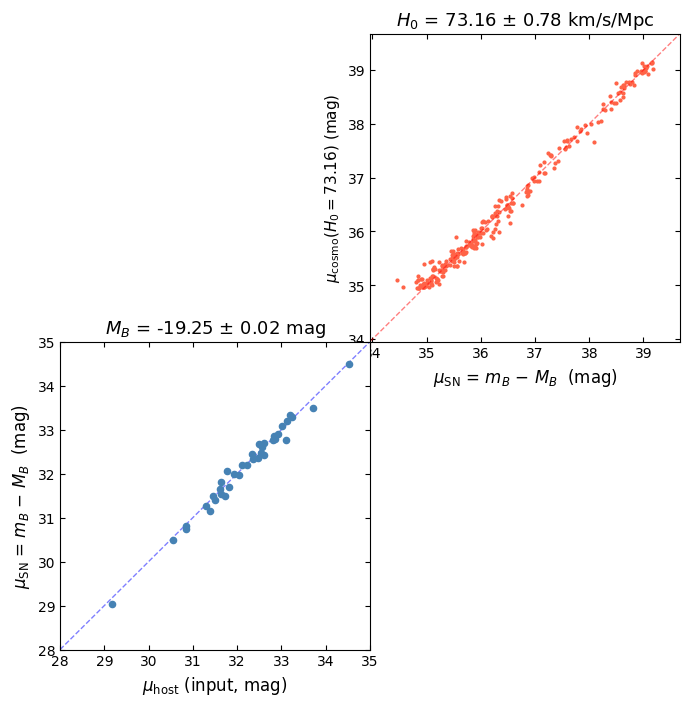

In [6]:
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=result['H0'], Om0=0.3, Ode0=0.7)

fig, axes = plt.subplots(2, 2, figsize=(8,8))
plt.subplots_adjust(wspace=0,hspace=0)
axes[1,1].axis('off')
axes[0,0].axis('off')

# ── μ_SN vs μ_Cepheid (per host mean) ─────────────────────────
ax = axes[1,0]
cal_mu     = y[cal.index] - result['M_B']
hosts_list = labels['host'].dropna().unique()
x_vals = [mu_host[h] for h in hosts_list]
y_vals = [cal_mu[labels[labels['host'] == h].index].mean() for h in hosts_list]
ax.scatter(x_vals, y_vals, s=20, color='steelblue', zorder=3,
           label='Calibrators (per-host mean)')
mu_range = np.linspace(28, 35, 100)
ax.plot(mu_range, mu_range, 'b--', lw=1, alpha=0.5, label='1:1 (perfect calibration)')
ax.set_xlabel('$\mu_{\\mathrm{host}}$ (input, mag)', fontsize=12)
ax.set_ylabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
ax.set_title(fr'$M_B$ = {result["M_B"]:.2f} ± {result["sigma_M_B"]:.2f} mag',
             fontsize=13)
ax.set_xlim(mu_range.min(), mu_range.max())
ax.set_ylim(mu_range.min(), mu_range.max())

# ── z_SN vs mu_SN ───────────────────────────────────
ax2 = axes[0,1]
hf_mu = merged.loc[hf.index]['m_b_corr'] - result['M_B']
hf_z  = merged.loc[hf.index]['zHD']
mu_range = np.linspace(hf_mu.min()-0.5, hf_mu.max()+0.5,100)
ax2.scatter(hf_mu, cosmo.distmod(hf_z), s=4, color='tomato', alpha=1,
            label='HF residuals')
ax2.plot(mu_range, mu_range, 'r--', lw=1, alpha=0.5)
ax2.set_xlim(mu_range.min(), mu_range.max())
ax2.set_ylim(mu_range.min(), mu_range.max())
ax2.set_xlabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
ax2.set_ylabel(rf'$\mu_{{\mathrm{{cosmo}}}} (H_0 = {result["H0"]:.2f})$ (mag)', fontsize=11)
ax2.set_title(fr'$H_0$ = {result["H0"]:.2f} ± {result["sigma_H0"]:.2f} km/s/Mpc',
             fontsize=13)

for ax in axes.flatten():
    ax.tick_params(direction='in',top=True, right=True)
plt.show()

## 6. Uniform distance-scale shift

A global bias in the Cepheid distance scale (e.g. from a zero-point error) shifts all host distances uniformly.  
This cell shows how H0 responds to a uniform shift Δμ applied to all hosts simultaneously.

The slope dH0/dΔμ ≈ −H0 × ln(10)/5 ≈ −34 km/s/Mpc per magnitude — a ~0.01 mag Cepheid zero-point error moves H0 by ~0.3 km/s/Mpc.

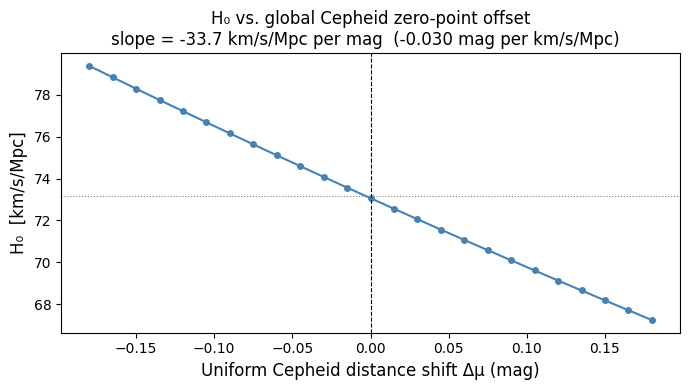

In [7]:
H0_base = result['H0']
shifts = np.linspace(-0.18, 0.18, 25)
H0_vals = []
for ds in shifts:
    mu_shifted = {h: mu_host[h] + ds for h in mu_host}
    r = solve_H0(mu_shifted, y=y, C=C, labels=labels, verbose=False)
    H0_vals.append(r['H0'])

H0_vals = np.array(H0_vals)
slope = np.polyfit(shifts, H0_vals, 1)[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, H0_vals, 'o-', color='steelblue', markersize=4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(H0_base, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Uniform Cepheid distance shift Δμ (mag)', fontsize=12)
ax.set_ylabel('H₀  [km/s/Mpc]', fontsize=12)
ax.set_title(f'H₀ vs. global Cepheid zero-point offset\n'
             f'slope = {slope:.1f} km/s/Mpc per mag  ({1/slope:.3f} mag per km/s/Mpc)  ')
plt.tight_layout()
plt.show()